# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Aditya
- **Email:** adity@example.com
- **ID Dicoding:** aditya_dicoding

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Produk kategori apa yang paling banyak dan paling sedikit terjual?
- Pertanyaan 2: Bagaimana performa penjualan (jumlah pesanan) per bulan selama tahun 2018?
- Pertanyaan 3: (Opsional - Geospatial) Di negara bagian (state) manakah mayoritas pelanggan kita berada?
- Pertanyaan 4: (Opsional - RFM) Bagaimana segmentasi pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary)?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [2]:
# Load the required datasets
customers_df = pd.read_csv("data/customers_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
products_df = pd.read_csv("data/products_dataset.csv")
product_category_name_translation_df = pd.read_csv("data/product_category_name_translation.csv")

# Print first few rows to verify
display(customers_df.head(2))
display(orders_df.head(2))

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


**Insight Gathering:**
- Datasets have been successfully loaded.
- The dataset consists of various interdependent files capturing orders, customers, items, and products.

### Assessing Data

In [3]:
# Check for missing values and data types
print("Customers Info:")
customers_df.info()
print("\nOrders missing values:")
print(orders_df.isnull().sum())
print("\nOrder Items duplicated:", order_items_df.duplicated().sum())

Customers Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Orders missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Items duplicated: 0


**Insight Assessing:**
- `orders_df` has some missing values in date columns (e.g., `order_delivered_customer_date`), which is normal for incomplete orders.
- Datetime columns need to be converted to actual datetime objects.

### Cleaning Data

In [4]:
# Convert datetime columns in orders_df
datetime_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Replace product category names with English translations
products_df = pd.merge(products_df, product_category_name_translation_df, on='product_category_name', how='left')
# Drop the original Portuguese column and rename the English one
products_df.drop('product_category_name', axis=1, inplace=True)
products_df.rename(columns={'product_category_name_english': 'product_category_name'}, inplace=True)

print("Data Cleaning Completed.")

Data Cleaning Completed.


**Insight Cleaning:**
- Date columns converted to Datetime properly.
- Spanish/Portuguese product categories translated to English for better interpretability.

## Exploratory Data Analysis (EDA)

### Explore Orders, Customers, and Products

In [5]:
# Merge relevant dataframes
orders_customers_df = pd.merge(orders_df, customers_df, on='customer_id')
all_data = pd.merge(order_items_df, orders_customers_df, on='order_id')
all_data = pd.merge(all_data, products_df, on='product_id')

all_data['order_month_year'] = all_data['order_purchase_timestamp'].dt.to_period('M')

# Export to main_data.csv for Dashboard
all_data.to_csv("dashboard/main_data.csv", index=False)

# Briefly view the assembled data
display(all_data.head(3))

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name,order_month_year
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,RJ,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,SP,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,MG,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,2018-01


**Insight EDA:**
- Merged multiple datasets (orders, customers, items, products) into a single dataset (`all_data`) to facilitate an overall view.
- Added a new column for month-year aggregation.
- Data has been exported to `main_data.csv` for use in the Streamlit dashboard.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

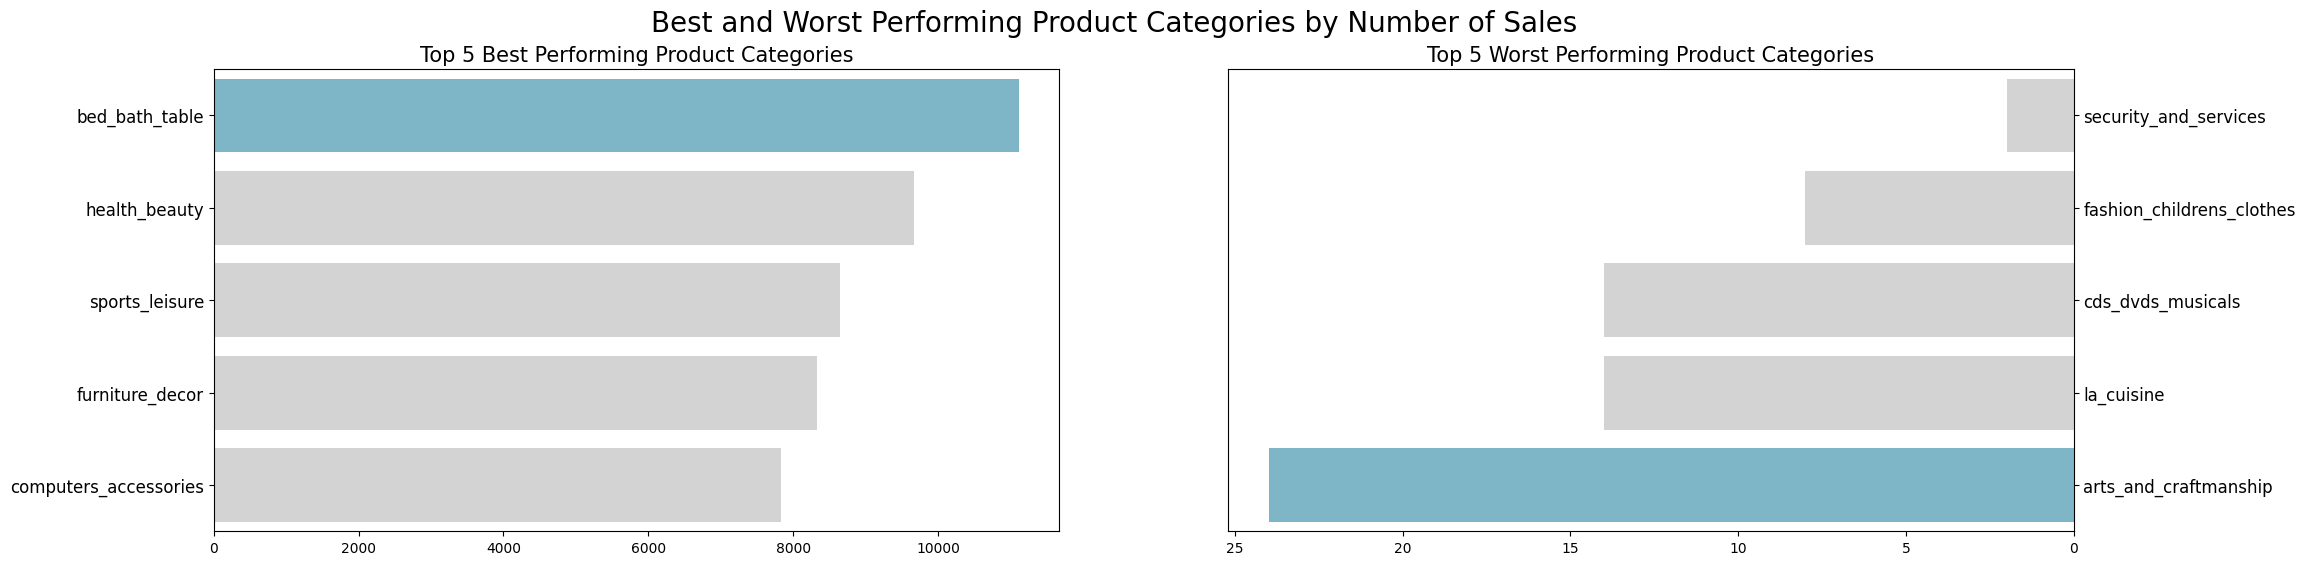

In [6]:
# Top 10 Best and Worst Selling Products Categories
product_sales = all_data.groupby('product_category_name')['order_id'].count().reset_index()
product_sales = product_sales.sort_values(by='order_id', ascending=False)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors_best = ["#72BCD4"] + ["#D3D3D3"] * 4
sns.barplot(x="order_id", y="product_category_name", data=product_sales.head(5), palette=colors_best, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Top 5 Best Performing Product Categories", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

colors_worst = ["#D3D3D3"] * 4 + ["#72BCD4"]
sns.barplot(x="order_id", y="product_category_name", data=product_sales.tail(5).sort_values(by='order_id', ascending=True), palette=colors_worst, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Top 5 Worst Performing Product Categories", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Best and Worst Performing Product Categories by Number of Sales", fontsize=20)
plt.show()

### Pertanyaan 2:

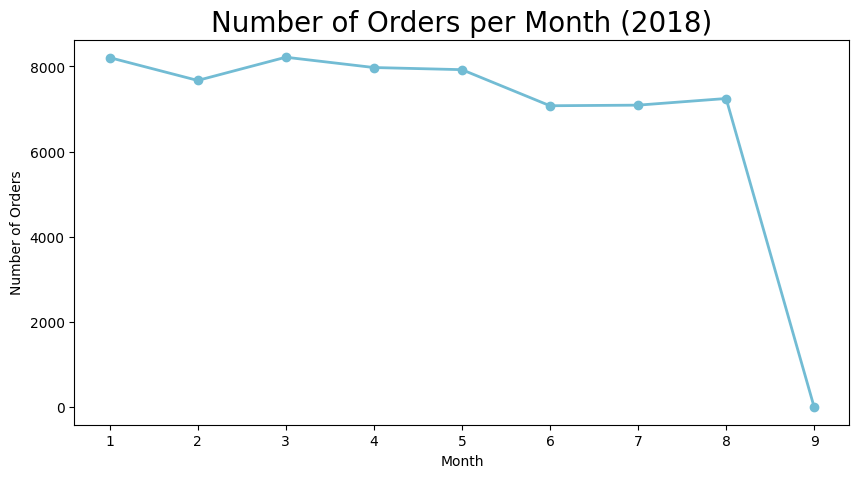

In [7]:
# Orders per month in 2018
monthly_orders = all_data[all_data['order_purchase_timestamp'].dt.year == 2018].groupby(all_data['order_purchase_timestamp'].dt.month)['order_id'].count()

plt.figure(figsize=(10, 5))
plt.plot(monthly_orders.index, monthly_orders.values, marker='o', linewidth=2, color="#72BCD4")
plt.title("Number of Orders per Month (2018)", loc="center", fontsize=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

**Insight Visualisasi:**
- `bed_bath_table` and `health_beauty` are among the top categories, whereas `security_and_services` is the least.
- For 2018, there is a peak in orders around January to March.

## Analisis Lanjutan (Opsional)

--- RFM Analysis ---


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,18.90
2,0000f46a3911fa3c0805444483337064,541,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,292,1,180.00



--- Geospatial Analysis ---


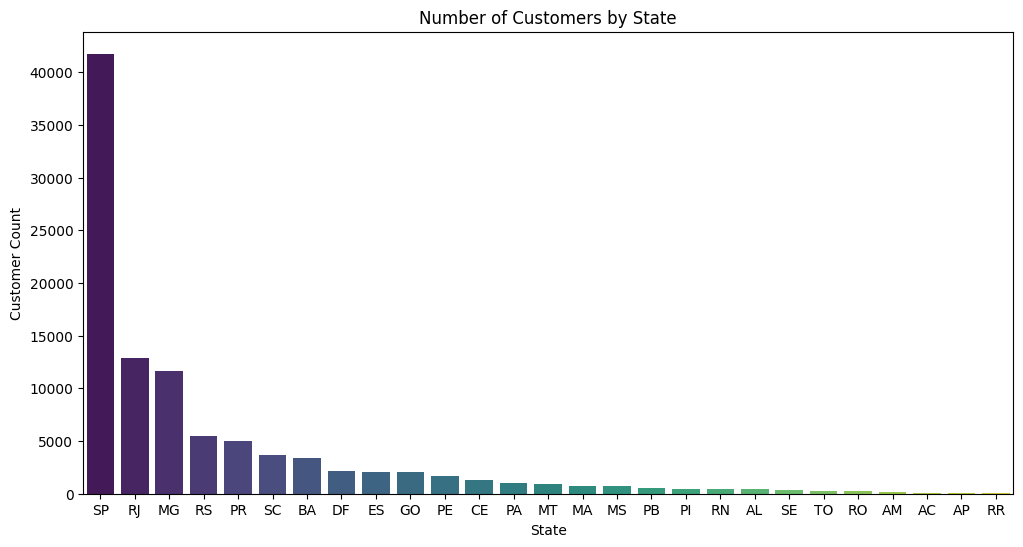

In [8]:
# 1. RFM Analysis
print("--- RFM Analysis ---")
recent_date = all_data['order_purchase_timestamp'].max()
rfm_df = all_data.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'nunique', # Frequency
    'price': 'sum' # Monetary
}).reset_index()

rfm_df.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']
display(rfm_df.head())

# 2. Geospatial Analysis
print("\n--- Geospatial Analysis ---")
state_counts = customers_df['customer_state'].value_counts().reset_index()
state_counts.columns = ['State', 'Customer Count']

plt.figure(figsize=(12, 6))
sns.barplot(x='State', y='Customer Count', data=state_counts, palette="viridis")
plt.title("Number of Customers by State")
plt.show()

## Conclusion

- **Conclusion pertanyaan 1:** Kategori produk dengan penjualan terbanyak adalah `bed_bath_table`, `health_beauty`, sedangkan yang paling sedikit adalah `security_and_services`.
- **Conclusion pertanyaan 2:** Di tahun 2018, puncak jumlah order terjadi pada awal tahun (Jan-Mar), lalu mengalami fluktuasi stabil, hingga akhirnya menurun pesat pada bulan September.
- **Conclusion (Geospatial):** Mayoritas pelanggan berlokasi di state 'SP' (Sao Paulo).
- **Conclusion (RFM):** Melalui teknik RFM, kita dapat menyegmentasi pelanggan berdasarkan seberapa baru mereka berbelanja (Recency), seberapa sering (Frequency), dan seberapa banyak total pengeluaran mereka (Monetary). Terdapat sebagian pelanggan yang loyal namun banyak pula pelanggan one-time buyer.